In [224]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

In [225]:
path = "D:\\Keobuabao_project\\dataset1"
IMG_SIZE = (224,224)
BATCH_SIZE = 32
SEED = 42

In [226]:
train = keras.utils.image_dataset_from_directory(
    path,
    batch_size = BATCH_SIZE,
    image_size = IMG_SIZE,
    seed = SEED,
    validation_split = 0.2,
    subset = "training"
)

Found 2188 files belonging to 3 classes.
Using 1751 files for training.


In [227]:
val = keras.utils.image_dataset_from_directory(
    path,
    batch_size = BATCH_SIZE,
    image_size = IMG_SIZE,
    seed = SEED,
    validation_split = 0.2,
    subset = "validation"
)

Found 2188 files belonging to 3 classes.
Using 437 files for validation.


In [228]:
class_names = train.class_names
class_names

['paper', 'rock', 'scissors']

In [229]:
for image_batch, labels_batch in train:
    print(image_batch.shape)
    print(labels_batch.shape)
    break

(32, 224, 224, 3)
(32,)


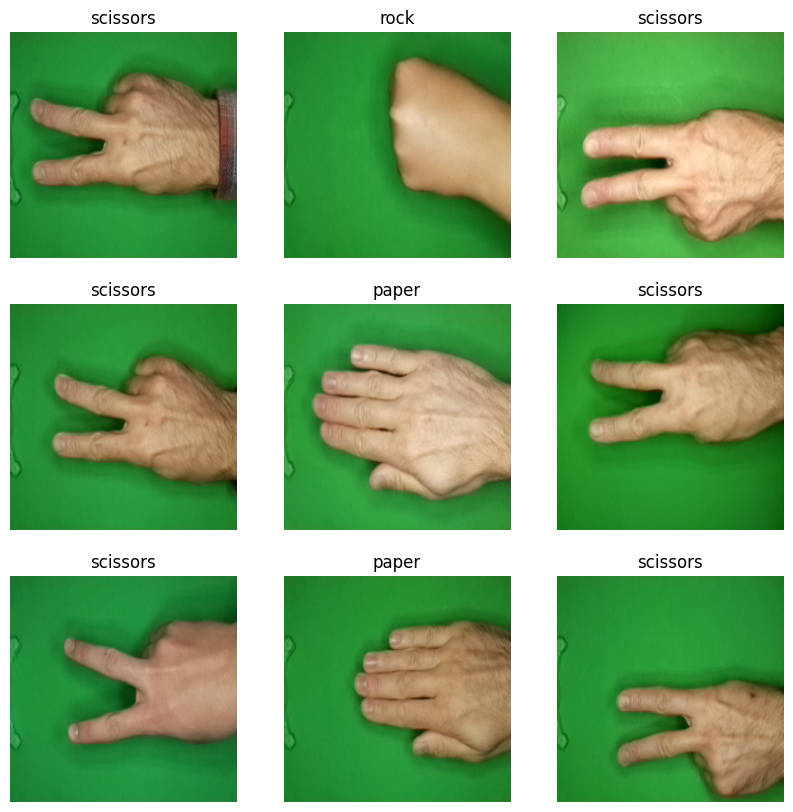

In [230]:
plt.figure(figsize=(10, 10))
for images, labels in train.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [231]:
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip("horizontal_and_vertical", seed=42),
  tf.keras.layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
  tf.keras.layers.RandomBrightness(factor = 0.2)
])

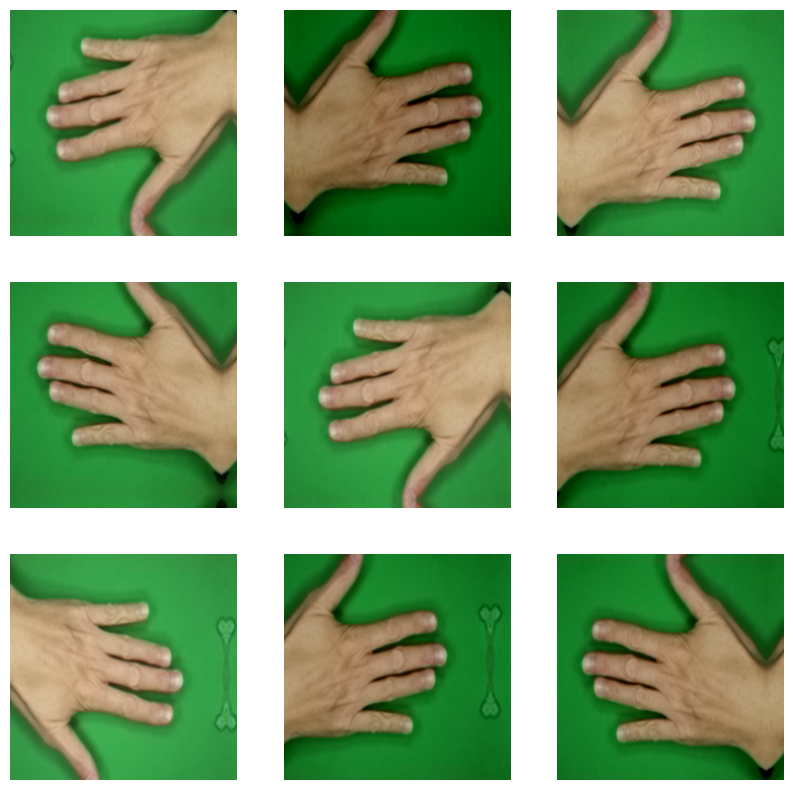

In [232]:
plt.figure(figsize=(10, 10))
for images, _ in train.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_images[0].numpy().astype("uint8"))
        plt.axis("off")

In [233]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape = (224,224,3)),
    data_augmentation,
    tf.keras.layers.Rescaling(1./255),
    
    tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(),
   
    tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    
    tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    
    tf.keras.layers.Flatten(),
    
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(3, activation = 'softmax')
])

In [234]:
model.compile(
    optimizer = 'adam',
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)

model.summary()

early_stop = keras.callbacks.EarlyStopping(monitor = "val_loss", mode = "auto", patience = 3, verbose = 1, restore_best_weights=False)

Model: "sequential_25"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential_24 (Sequential)  (None, 224, 224, 3)       0         
                                                                 
 rescaling_14 (Rescaling)    (None, 224, 224, 3)       0         
                                                                 
 conv2d_36 (Conv2D)          (None, 224, 224, 32)      896       
                                                                 
 max_pooling2d_36 (MaxPooli  (None, 112, 112, 32)      0         
 ng2D)                                                           
                                                                 
 conv2d_37 (Conv2D)          (None, 112, 112, 64)      18496     
                                                                 
 max_pooling2d_37 (MaxPooli  (None, 56, 56, 64)        0         
 ng2D)                                               

In [235]:
history = model.fit(train, epochs=50, validation_data = val, callbacks=[early_stop])

Epoch 1/50
55/55 [==============================] - 29s 515ms/step - loss: 1.1930 - accuracy: 0.4500 - val_loss: 0.7303 - val_accuracy: 0.7895
Epoch 2/50
55/55 [==============================] - 29s 522ms/step - loss: 0.7320 - accuracy: 0.6996 - val_loss: 0.3197 - val_accuracy: 0.9222
Epoch 3/50
55/55 [==============================] - 28s 501ms/step - loss: 0.4513 - accuracy: 0.8235 - val_loss: 0.1969 - val_accuracy: 0.9428
Epoch 4/50
55/55 [==============================] - 29s 530ms/step - loss: 0.4015 - accuracy: 0.8527 - val_loss: 0.2788 - val_accuracy: 0.9085
Epoch 5/50
55/55 [==============================] - 28s 499ms/step - loss: 0.3525 - accuracy: 0.8721 - val_loss: 0.1781 - val_accuracy: 0.9474
Epoch 6/50
55/55 [==============================] - 27s 498ms/step - loss: 0.3165 - accuracy: 0.8801 - val_loss: 0.1551 - val_accuracy: 0.9405
Epoch 7/50
55/55 [==============================] - 28s 514ms/step - loss: 0.2959 - accuracy: 0.8983 - val_loss: 0.1455 - val_accuracy: 0.9542

In [236]:
from pathlib import Path
save_dir = Path('models')
save_dir.mkdir(exist_ok=True) 

model_path = save_dir / 'testkeobuabao2.keras'
model.save(model_path)

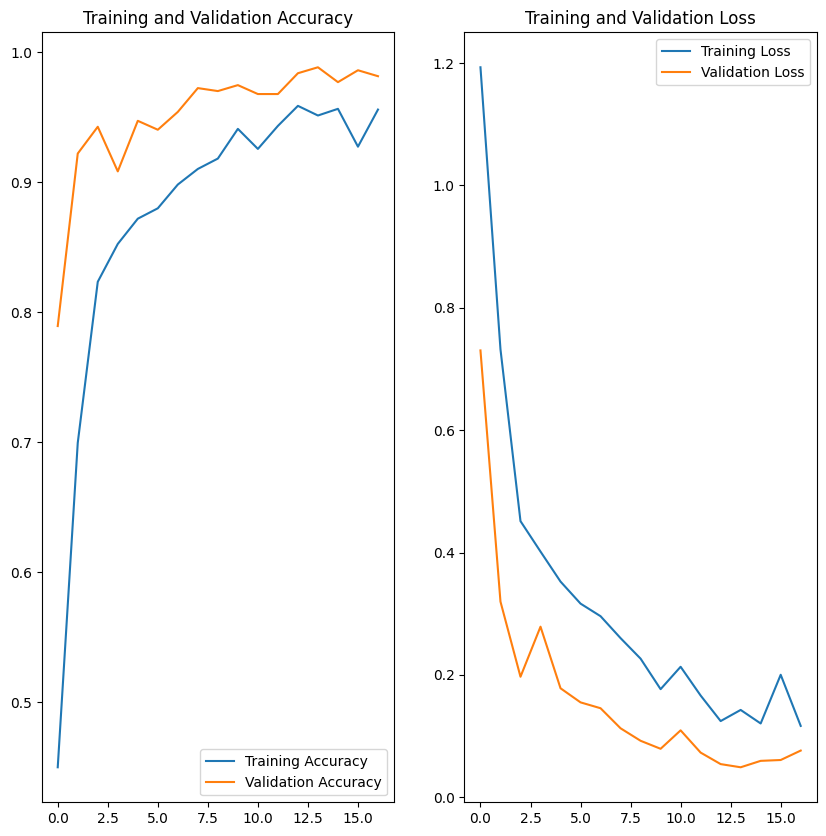

In [237]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(10,10))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [238]:
import numpy as np
import cv2 
from tensorflow import keras

model = keras.models.load_model("models/testkeobuabao2.keras")
class_name = ["Bao", "Bua", "Keo"]

img_path = "D:\\Keobuabao_project\\042a82f6-cacf-4d46-8263-5746625f2d0a.jpg"
img = cv2.imread(img_path)

img_resize = cv2.resize(img, IMG_SIZE)
img_color = cv2.cvtColor(img_resize, cv2.COLOR_BGR2RGB)

img_input = np.expand_dims(img_color, axis = 0)

predict = model.predict(img_input, verbose = 0)
label = class_name[np.argmax(predict)]
score = np.max(predict)

print(f"ket qua: {label}, ti le: {score}")

ket qua: Bao, ti le: 0.9962393045425415
